# q3dfit example notebook: rest frame optical, Gemini+GMOS single spectrum of ORC2/3C from [Rupke et al. 2024](https://ui.adsabs.harvard.edu/abs/2024ApJ...967...51R/abstract)

<h3><font color='teal'>Installation of the environment and the package are described <a href="https://q3dfit.readthedocs.io/">here</a>. </font></h3>

This Jupyter notebook allows you to run Q3Dfit, a PSF decomposition and spectral analysis package tailored for JWST NIRSpec and MIRI IFU observations. 

Q3Dfit is developed as a science-enabling data product by the Early Release Science Team #1335 Q3D. You can find more information about this ERS program **Q3D** [here](https://q3d.github.io/) and [here](https://www.stsci.edu/jwst/science-execution/approved-programs/dd-ers/program-1335).

The software is based on the existing package IFSFIT developed by Dave Rupke (see [ADS link](https://ui.adsabs.harvard.edu/abs/2017ApJ...850...40R/abstract)).

The following notebook will guide you through the initialization procedure and will then perform the analysis. 

## 1. Initialization

In [2]:
import os.path
import numpy as np
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
# Be sure to set the path to q3dfit correctly.
# For instance:
#import sys
#sys.path.append('/Users/jwstuser/q3dfit/')
#import sys
#sys.path.append("../")

### 1.0. Setting up the directory tree

Define the directories in which the data that you want to analyse are stored and the output directories. We recommend creating a working directory that you name after your target, in which all outputs from q3dfit will be saved. Then download test data.

In [4]:
# Base directory (book-keeping)
volume = 'orc23c/'
# prefix label for output files
label = 'orc23c'
# Input directory
indir = volume
if not os.path.exists(indir):
    os.makedirs(indir)
# Output directory
outdir = volume
if not os.path.exists(outdir):
    os.makedirs(outdir)
# Initialization file (q3di.npy) directory
initdir = volume
# Output logfile
logfile = os.path.join(outdir, label+'-fitlog.txt')

Download data from public Box folder:

In [71]:
# make tuples of urls and download filenames
# stellartemplates = stellar population synthesis templates
infile_tup=('https://rhodes.box.com/shared/static/1k743ttc75vd0aoal4w7j6bhyvcgbz44.fits','orc23c.fits')
stellartemplates_tup=('https://rhodes.box.com/shared/static/u6jy6thc20le24nx2ohhckbnz55myyrd.npy','bpass_v2.3.a+00_z001to040_bin_lam2400to10000.npy')
# download files; by default don't force overwrite and take first element of output
from q3dfit.nonfit.jnb import download_files
infile = download_files(infile_tup, indir, force=False)[0]
stellartemplates = download_files(stellartemplates_tup, indir, force=False)[0]
# add subdirectory to filenames
infile = os.path.join(indir, infile)
stellartemplates = os.path.join(indir, stellartemplates)

orc23c.fits already exists, skipping download...
bpass_v2.3.a+00_z001to040_bin_lam2400to10000.npy already exists, skipping download...


### 1.1. Initializing the fit

The initial parameters of the fit are stored in an object of class `q3din`. Each parameter or attribute of this class controls some aspect of the fit process. We start by instantiating the class. The only required parameters at the outset are the input data and label; the label is used for output file naming. 

In [6]:
from q3dfit.q3din import q3din
q3di = q3din(infile, label, outdir=outdir, logfile=logfile, dqext=None)

Here's a list of the fit parameters that are automatically set:

In [7]:
q3di.__dict__

{'infile': 'orc23c/orc23c.fits',
 'label': 'orc23c',
 'argsreadcube': {},
 'cutrange': None,
 'fitrange': None,
 'logfile': 'orc23c/orc23c-fitlog.txt',
 'name': None,
 'outdir': 'orc23c/',
 'spect_convol': {},
 'vacuum': True,
 'zsys_gas': None,
 'datext': 1,
 'varext': 2,
 'dqext': None,
 'docontfit': False,
 'dolinefit': False,
 'savematrix': False}

### 1.2. Setting up the data and models

Some general information about your data. `argsreadcube` is a dictionary of attributes sent to the `Cube` class.
- For non-JWST data, set `wmapext` to `None`. The WMAP extension is a [3-D weight image](https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/science_products.html) giving the relative weights of the output spaxels.
- Microns are the wavelength unit used internally, but `q3dfit` can accept input/output in Å.
- `q3dit` does calculations in f$_\lambda$ space, but assumes input units of MJy/sr, the JWST default. Other input wavelength units can be specified. In this case, the data is in erg/s/cm$^2$/Å. The output flux units will be the same. We also normalize to minimize numerical issues in the fitting.

In [8]:
q3di.argsreadcube = {'wmapext': None,
                     'waveunit_in': 'Angstrom',
                     'fluxunit_in': 'erg/s/cm2/Angstrom',
                     'waveunit_out': 'Angstrom',
                     'fluxunit_out': 'erg/s/cm2/Angstrom',
                     'fluxnorm': 1e-17}
cube = q3di.load_cube()

Cube: No flux units in header; using erg/s/cm2/Angstrom
Cube: No pixel area in header or specified in call; no correction for surface brightness flux units.
Size of data cube: [1, 1, 3543]
Wavelength range: [4735.71529, 10334.76647] Angstrom
Dispersion: 1.58076 Angstrom
Input flux units: erg/s/cm2/Angstrom
Input wave units: Angstrom
Output flux units: erg/s/cm2/Angstrom
Output wave units: Angstrom
NB: q3dfit uses output units for internal calculations.


Let's plot the spectrum to see how it looks. The arguments are column and row in unity-offset integers; since this is a single spectrum, we specify 1 for both. The flux units are as specified above.

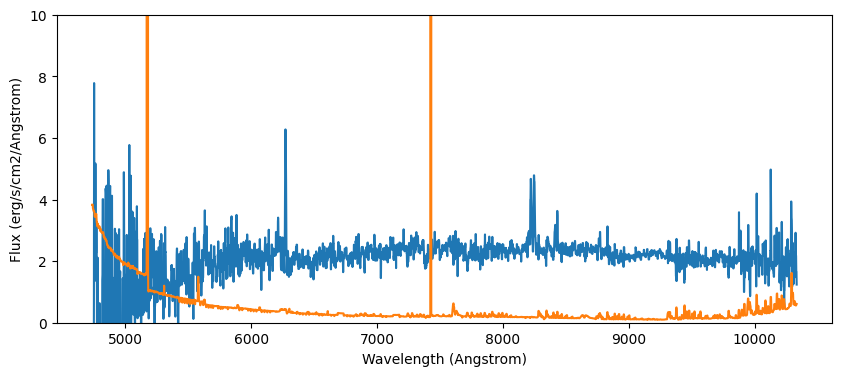

In [9]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=[10,4])
spec_test = cube.specextract(1, 1, ylim=[0.,10.], medfilt=3)

Name and systemic redshift of the galaxy. `zsys_gas` is used in this notebook in initializing the arrays of initial guesses below.

In [10]:
q3di.name = 'ORC23C'
q3di.zsys_gas = 0.2521

Wavelength range over which to fit data. The user can also specify sets of regions to ignore in the fit.

In [11]:
q3di.fitrange = np.array([4735.,10335.])

### 1.3. Setting up the fitting parameters

#### 1.3.1. Emission-line parameters

What lines do you want to fit? You can choose from the linelists available [here](https://github.com/Q3D/q3dfit/tree/main/q3dfit/data/linelists), or in `q3dfit/data/linelists/`.

In [12]:
lines = ['Halpha', 'Hbeta', '[OI]6300', '[OI]6364', '[OIII]4959', '[OIII]5007', '[NII]6548', 
         '[NII]6583', '[SII]6716', '[SII]6731', '[ArIII]7138','[ArIII]7753']

This block sets up initial conditions for the emission-line fit. This initialization method adds a number of new attributes to the object. Emission lines are set to a common redshift and velocity dispersion, set to `q3di.zsys_gas` and 50 km/s by default. However, different sets of emission lines can have different velocities and linewidths by specifying different lines to which to tie particular emission lines. Different initial conditions can also be set on a line-by-line basis.

The default number of velocity components is 1. 

`siglim_gas` sets lower and upper bounds for the Gaussian width (sigma) of the emission line. These limits can be set for all components by defining a 2-element array when initializing the fit. The limits can also be set for individual components later by defining an (1 x 1 x Ncomp x 2) array, or by modifying the initial array using slicing.

In [13]:
q3di.init_linefit(lines, linetie='Halpha', siglim_gas=np.array([1., 1500.]))
q3di.__dict__.keys()

dict_keys(['infile', 'label', 'argsreadcube', 'cutrange', 'fitrange', 'logfile', 'name', 'outdir', 'spect_convol', 'vacuum', 'zsys_gas', 'datext', 'varext', 'dqext', 'docontfit', 'dolinefit', 'savematrix', 'ncols', 'nrows', 'cubedim', 'lines', 'maxncomp', 'fcnlineinit', 'argslineinit', 'argslinelist', 'argslinefit', 'checkcomp', 'fcncheckcomp', 'argscheckcomp', 'perror_errspecwin', 'perror_residwin', 'perror_useresid', 'linetie', 'linevary', 'ncomp', 'siginit_gas', 'siglim_gas', 'zinit_gas'])

Let's see what one of these new attributes looks like, just for fun:

In [14]:
q3di.zinit_gas

{'Halpha': array([[[0.2521]]]),
 'Hbeta': array([[[0.2521]]]),
 '[OI]6300': array([[[0.2521]]]),
 '[OI]6364': array([[[0.2521]]]),
 '[OIII]4959': array([[[0.2521]]]),
 '[OIII]5007': array([[[0.2521]]]),
 '[NII]6548': array([[[0.2521]]]),
 '[NII]6583': array([[[0.2521]]]),
 '[SII]6716': array([[[0.2521]]]),
 '[SII]6731': array([[[0.2521]]]),
 '[ArIII]7138': array([[[0.2521]]]),
 '[ArIII]7753': array([[[0.2521]]])}

##### Line ratio constraints
Lines with ratios fixed by atomic physics have their ratios fixed automatically. Other ratios can have bound constraints applied, or they can be fixed to a particular value. Some density-sensitive ratios have bounds applied; these limits can be found in [this table](/q3dfit/data/linelists/doublets.tbl).

See [the documentation](https://q3dfit.readthedocs.io/stable/q3dfit.html#q3dfit.lineinit.lineinit) for more details.

- `line1`, `line2`, and `comp` are required. `comp` is an array of velocity components (zero-indexed) on which to apply the constraints, one array for each pair of lines.
- `value` is the initial value of `line1`/`line2`. Presently, if `value` is specified for one pair of lines, it must be specified for all. Otherwise, the initial value is determined from the data.
- The ratio can be `fixed` to the initial value. Presently, if `fixed` is defined, it must be set to `True` or `False` for all pairs of line.
- If the ratio is not `fixed`, `lower` and `upper` limits can also be specified. (If they are not, and the line pair is a doublet in the doublets.tbl file, then the lower and upper limits are set using the data in that file.) Presently, if `lower` or `upper` is defined here for one set of lines, it must be defined here for every pair of lines.

In [15]:
#q3di.argslineinit = dict()

# Required columns:
#line1 = ['[NI]5200']
#line2 = ['[NI]5198']
#comp = np.array([[0]], dtype=np.int32)
# Optional columns:
#value = [2./3.]
#fixed = [True]

# Write table
#from astropy.table import QTable
#lineratio = QTable([line1, line2, comp, value, fixed], names=['line1', 'line2', 'comp', 'value', 'fixed'])
#q3di.argslineinit['lineratio']=lineratio

##### Spectral resolution convolution

If no convolution is desired: do not set `spect_convol` (or set it to `{}`, or `None`).

If convolution is desired: `spect_convol` is a dictionary with two optional tags.
- `ws_instrum`: This specifies the desired convolution method. The syntax is: `{INSTRUMENT:[GRATING]}`. The values for `INSTRUMENT` and `GRATING` for pre-defined dispersion files should mirror the filename syntax in `q3dfit/data/dispersion_files/`. E.g., for file `jwst_miri_ch1a_disp.fits`, `INSTRUMENT=jwst_miri` and `GRATING=ch1a`. (Case is irrelevant. For convolution with a constant value of spectral resolution [R], Δλ FWHM in [$\mu$m], or velocity in [km/s], set `INSTRUMENT = flat` and `GRATING = ` a string containing `R`, `dlam`, or `dvel` and the corresponding numerical quantity. More thana one instrument and/or grating can be set.
- `dispdir`: Directory in which to find the dispersion files. If not set, the default `q3dfit` directory is searched.

Examples: 
1. flat R=500: `spect_instrum = {'flat':['R500']}`
2. flat velocity FWHM = 30km/s: `spect_instrum = {'flat':['dvel30']}`
3. flat Δλ FWHM = 4 Å: `spect_instrum = {'flat':['dlambda0.0004']}`
4. JWST NIRSPEC / G140M: `spect_instrum = {'JWST_NIRSPEC':['G140M']}`
5. Spitzer IRS SH+LH: `spect_instrum = {'Spitzer_IRS':['ch1_sh','ch1_lh']}`

Note in the final example that two gratings are set.

This case applies to the GMOS B600 grating. Gemini website says R = 1918 at 7640 A for 0.5" slit. This gives 5.97 A FWHM for our 0.75" slit.

In [16]:
q3di.spect_convol['ws_instrum'] = {'flat': ['dlambda5.97']}

##### Creating convolution files (optional)

To create a dispersion file, use one of the following methods. The second two involve specific subclasses of the dispersion class used for the instrument/grating file or constant dispersion formats 

1. Create a `dispersion` object and use the `dispersion.write()` method. For example:

```
dispEx1 = dispersion()
dispEx1.write('/dispdir/disp.fits', wave=np.linspace(5.,10.,50), type='R', disp=np.full(50, 500.))
```

2. Create a `InstGratDispersion` object to attach instrument and grating information to the object and define the output filename in the `q3dfit` format. Use the `InstGratDispersion.writeInstGrat()` method.

```
dispEx2 = InstGratDispersion(`Keck_ESI`,`echellette`, dispdir=`/dispdir/`)
dispEx2.writeInstGrat(wave=np.linspace(5.,10.,50), type='dvel', disp=np.full(50, 30.))
```

3. Create a `FlatDispersion` object and use the `FlatDispersion.writeFlat()` method. This requires only a single value for the dispersion quantity and also defines the filename automatically.
```
dispEx3 = FlatDispersion(0.0004,`dlam`,wave=np.linspace(5.,10.,50))
dispEx3.writeFlat(dispdir=`/dispdir/`)
```

##### Options to `lmfit` and `scipy.optimize.least_squares` (or `scipy.optimize.leastsq`, or other optimizer)
`q3dfit` uses the `fit` method of the [`Model` class](https://lmfit.github.io/lmfit-py/model.html#lmfit.model.Model) of `lmfit` to call [`scipy.optimize.least_squares`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html), or another method of choice. Both the method and function have options which can be changed in the `q3dfit` call. To do so, add key/value pairs to the `argslinefit` dictionary, which in turn is a keyword of the `q3di` dictionary.

The options to the `fit` method in `lmfit` that can currently be changed are the following:
- `method`: in particular, `leastsq` may be faster than `least_squares`
- `max_nfev`: maximum number of function evaluations before the fit aborts
- `iter_cb`: if this is set to "per_iteration", the value of every model parameter at each function evaluation is printed to `stdout`

Most parameters of `least_squares`/`leastsq` can be changed in this way, unless they are specifically set by `lmfit`. Examples which have been tested include:
- `x_scale`: jac
- `tr_solver`: lsmr
- `loss`: soft_l1
- `ftol`, `gtol`, `xtol`
- `epsfcn`

In [17]:
q3di.argslinefit=dict()
#q3di.argslinefit['method'] = 'leastsq'
#q3di.argslinefit['iter_cb'] = 'per_iteration'
# As an example, to change the criteria for fit convergence from the defaults of 1.e-8 to 1.e-10:
q3di.argslinefit['ftol'] = 1.e-10
q3di.argslinefit['gtol'] = 1.e-10
q3di.argslinefit['xtol'] = 1.e-10
q3di.argslinefit['x_scale'] = 'jac'
q3di.argslinefit['tr_solver'] = 'lsmr'
# .. and the "suitable step length for the forward- difference approximation of the Jacobian. Normally the actual step length will be sqrt(epsfcn)*x"
# this is only for scipy.optimize.leastsq
#q3di.argslinefit['epsfcn'] = 1.e-15

#### 1.3.2 Continuum parameters

We next initialize the continuum. As part of this, we give it the name of our continuum fitting function, and then add some stellar templates to fit. A default stellar library from [BPASS v2.3](https://bpass.auckland.ac.nz) is included. `q3dfit` also has a function to convert the BPASS model directory, available at the BPASS website, to the custom format used by `q3dfit`.

The stellar library is convolved with the instrumental spectral resolution, if specified above, before fitting.

In [18]:
# option 1
templatefile = stellartemplates
# option 2
#from q3dfit import templates
#templatefile = indir+'bpass-v2.3.a+00-2000to10000A-z008to040.npy'
#templates.read_bpass('/root/directory/to/bpass_v2.3.a+00/',
#                      templatefile,
#                      waverange=[2000.,10000.],
#                      zs=[0.008,0.010,0.014,0.020,0.030,0.040])

In [19]:
q3di.init_contfit('ppxf')
q3di.startempfile = templatefile
q3di.startempwaveunit = 'Angstrom'
q3di.__dict__.keys()

dict_keys(['infile', 'label', 'argsreadcube', 'cutrange', 'fitrange', 'logfile', 'name', 'outdir', 'spect_convol', 'vacuum', 'zsys_gas', 'datext', 'varext', 'dqext', 'docontfit', 'dolinefit', 'savematrix', 'ncols', 'nrows', 'cubedim', 'lines', 'maxncomp', 'fcnlineinit', 'argslineinit', 'argslinelist', 'argslinefit', 'checkcomp', 'fcncheckcomp', 'argscheckcomp', 'perror_errspecwin', 'perror_residwin', 'perror_useresid', 'linetie', 'linevary', 'ncomp', 'siginit_gas', 'siglim_gas', 'zinit_gas', 'fcncontfit', 'argscontfit', 'dividecont', 'av_star', 'keepstarz', 'maskwidths', 'maskwidths_def', 'masksig_secondfit', 'nolinemask', 'nomaskran', 'startempfile', 'startempvac', 'startempwaveunit', 'siginit_stars', 'zinit_stars'])

`q3dfit` first masks emission lines before fitting. The default mask value is 500 km/s for each velocity component for the first fit. During the second fit, the mask value is set automatically using the best-fit linewidths determined from the first fit.

In [20]:
q3di.maskwidths_def

500.0

The continuum fitting parameters specified here are for a `ppxf` fit. These are presently the only options available.
- `add_poly_degree` = [Optional] additive Legendre polynomial for host [starlight] component. -1 means no polynomial. Default is 4.
- `mult_poly_degree` = [Optional] multiplicative Legendre polynomial for host [starlight] component. 0 means normal scaling. Default is 0.
- `av_star` = [Optional] initial guess for Calzetti (2000) reddening. Default is None, which means no reddening is fit.
- `savematrix` = [Optional] tells q3dfit to save the template matrix in order to decompose the fit later

In [21]:
q3di.av_star = 0.1
q3di.argscontfit = dict()
q3di.argscontfit['add_poly_degree'] = -1
q3di.argscontfit['mult_poly_degree'] = 0

q3di.savematrix = True

## 2. Run fit

Run the fit. Choose `quiet=False` for verbose output. An output dictionary for each spaxel is saved to a numpy binary file labeled with prefix `q3di['label']` and suffix `_col_row.npy`. See note above on multicore processing.

In [110]:
from q3dfit.q3df import q3dfit
q3dfit(q3di, quiet=False)

Cube: No flux units in header; using erg/s/cm2/Angstrom
Cube: No pixel area in header or specified in call; no correction for surface brightness flux units.
Size of data cube: [1, 1, 3543]
Wavelength range: [4735.71529, 10334.76647] Angstrom
Dispersion: 1.58076 Angstrom
Input flux units: erg/s/cm2/Angstrom
Input wave units: Angstrom
Output flux units: erg/s/cm2/Angstrom
Output wave units: Angstrom
NB: q3dfit uses output units for internal calculations.
Core 1: # spaxels fit=1
[spec]=[1] out of [1]
FITLOOP: First call to FITSPEC
 Best Fit:       Vel     sigma
 comp.  0:        90       149
Stars Attenuation A_V: 0.311
chi2/DOF: 1.223; DOF: 3370; degree = -1; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 18; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 21/451
FITSPEC: Continuum fit took 0.9 s.
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.0056e+03                                    1.

## 3. Plot fit results

Load the output of a fit.

In [111]:
from q3dfit.q3dout import load_q3dout
q3do = load_q3dout(q3di)

Set up the line plot parameters using a dictionary.

* `nx`: Number of subplots in the horizontal direction (default = 1)
* `ny`: Number of subplots in the vertical direction (default = 1)
* Required: choose one options for centerting the plot
    - `line`: a string list of line labels
    - `center_obs`: a float list of wavelengths of each subplot center, in the observed (plotted) frame
    - `center_rest`: a float list of wavelengths of each subplot center, in the rest frame, which are converted to obs. frame
* `size`: float list of widths in wavelength space of each subplot; if not specified (default = 300 $Å$)
* `questfit`: set to `True` to use plot tailored for rest-frame mid-IR spectra

In [112]:
argsplotline = dict()
argsplotline['nx'] = 3
argsplotline['ny'] = 2
argsplotline['line'] = ['[OIII]4959', '[OI]6300', 'Halpha', '[SII]6716', '[ArIII]7138']
argsplotline['size'] = np.array([300.,200.,150.,100.,100.])
argsplotline['figsize'] = (10,8)
argsplotline['mode'] = 'light'

Run the plot method. The output can be saved to a file by specifying `savefig=True`. A default filename is used, which can be overridden by specifying `outfile=file`. The output file will have the suffix `_lin` attached, so that the actual filename will be "file_lin.png". The file format, and other [pyplot.savefig](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html) options, can be added to the `plotargs` dictionary as, e.g., `'argssavefig': {'format': '.pdf'}`.

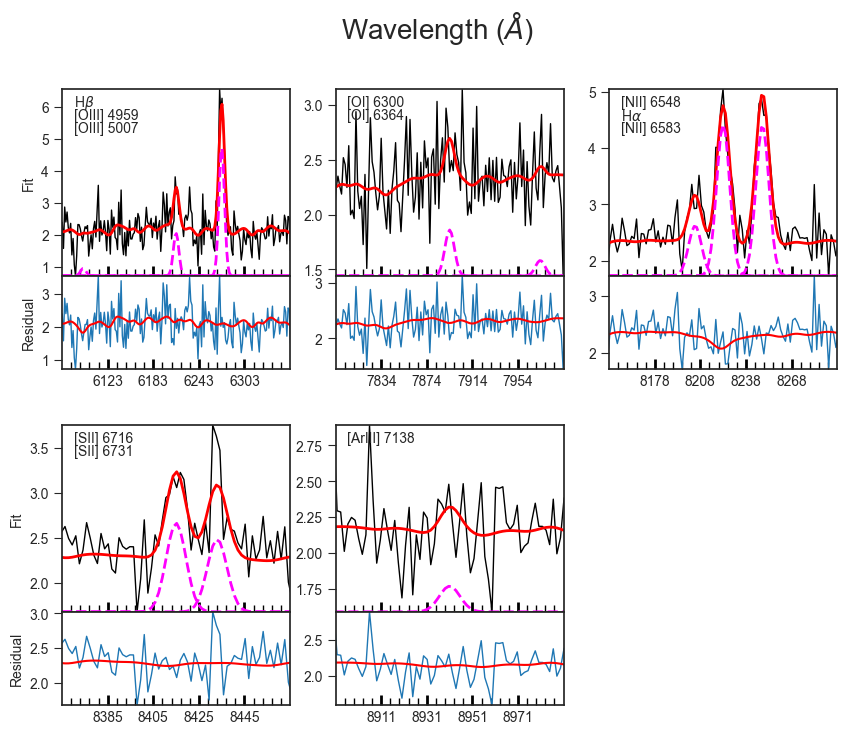

In [113]:
q3do.plot_line(q3di, savefig=True, plotargs=argsplotline)

Some line fluxes:

In [114]:
q3do.line_fitpars['flux']

Halpha,Hbeta,[OI]6300,[OI]6364,[OIII]4959,[OIII]5007,[NII]6548,[NII]6583,[SII]6716,[SII]6731,[ArIII]7138,[ArIII]7753
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
28.853254394202366,2.092377745857909,4.377564076316799,1.4738902540263168,12.163058823434696,36.84185729678651,9.512066207827722,28.690467327139057,10.758618394347558,8.813791428541135,2.0412086021891653,1.482765344286588e-06


Flux units are

In [115]:
from astropy import units as u
q3do.fluxnorm*u.Unit(q3do.linefluxunit)

<Quantity 1.e-17 erg / (s cm2)>

And a redshift and linewidth:

In [116]:
print(f'{q3do.line_fitpars['z']['Halpha'].value[0]:.5f} +/- {q3do.line_fitpars['zerr']['Halpha'].value[0]:.5f}')
print(f'{q3do.line_fitpars['sigma']['Halpha'].value[0]:.1f} +/- {q3do.line_fitpars['sigmaerr']['Halpha'].value[0]:.1f} km/s')

0.25262 +/- 0.00002
126.5 +/- 6.5 km/s


Run two methods. The first computes the continuum values to plot, and the second does the plotting. The `plot_cont` method calls the continuum plotting function `plotcont`.

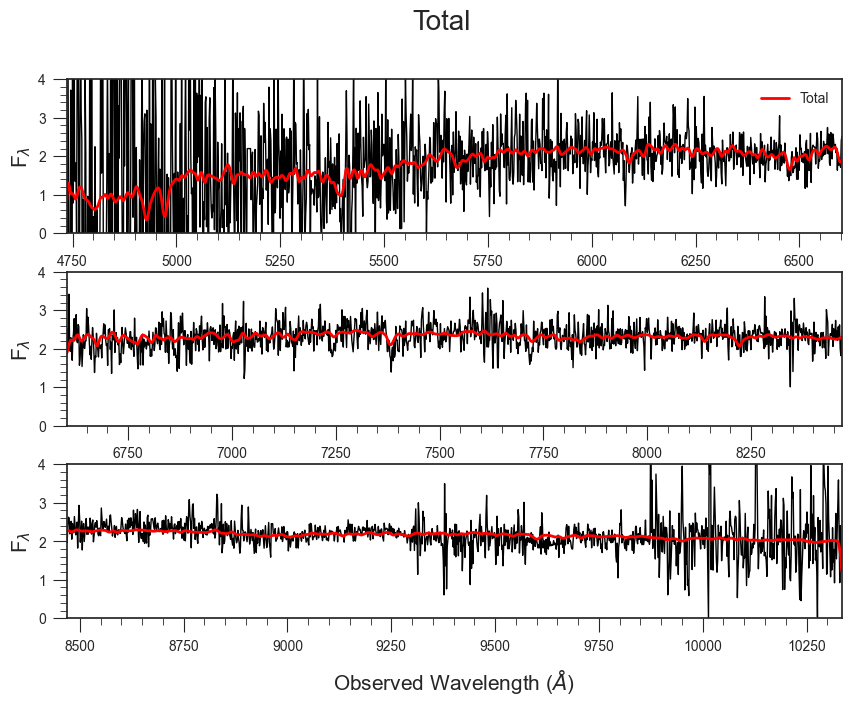

In [117]:
q3do.sepcontpars(q3di)
q3do.plot_cont(q3di, savefig=True, plotargs={'figsize': (10,7), 'yran': [0.,4.], 'mode': 'light'})

Now print some of the stellar parameter outputs:

In [118]:
q3do.print_stelpars()

Stellar fit parameters
----------------------
Attenuation: 0.30
Velocity dispersion: 148+/-28 km/s
Redshift: 0.25246+/-0.00008


We can also see what templates were used in the fit:

In [119]:
# first we need to call some methods to extract the revlevant template data
# we can specify a minimum weight for templates to be included, by default it is 0.0
q3do.get_template_data(q3di, min_weight=0.0)
# find_poulation_stats can be called with a fixed value for the stellar population mass in solar masses if not avaliable in the templates:
# q3do.find_population_stats(q3di.startempfile, fixed_mass=1.e6)
# but by default it will use the mass in the templates if available, or else it will use a fixed value of 1.e6 solar masses.
# additionally if any rescaling has been applied to the data aside from the fluxnorm value used when reading the cube, 
# we can specify that with the data_scale parameter, which is 1.0 by default.
q3do.find_population_stats(q3di.startempfile, data_scale=1.0)

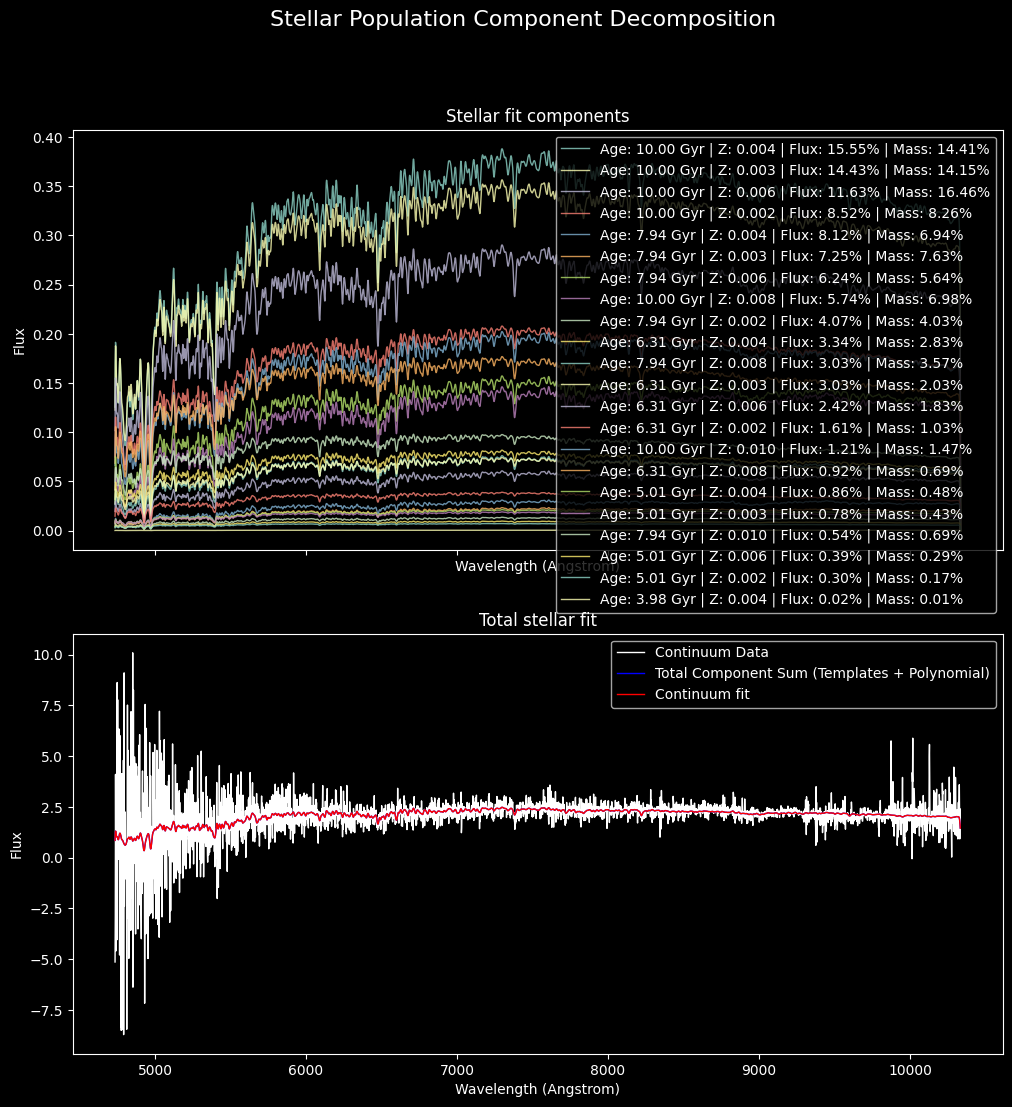

In [120]:
# Now we can plot the continuum components.
# By default, it will plot the weighted convolved templates, but you can also plot the weighted unconvolved templates with the argument:
# plot_raw_templates = True
q3do.plot_cont_components(q3di, savefig=True, plotargs={'mode': 'dark'})

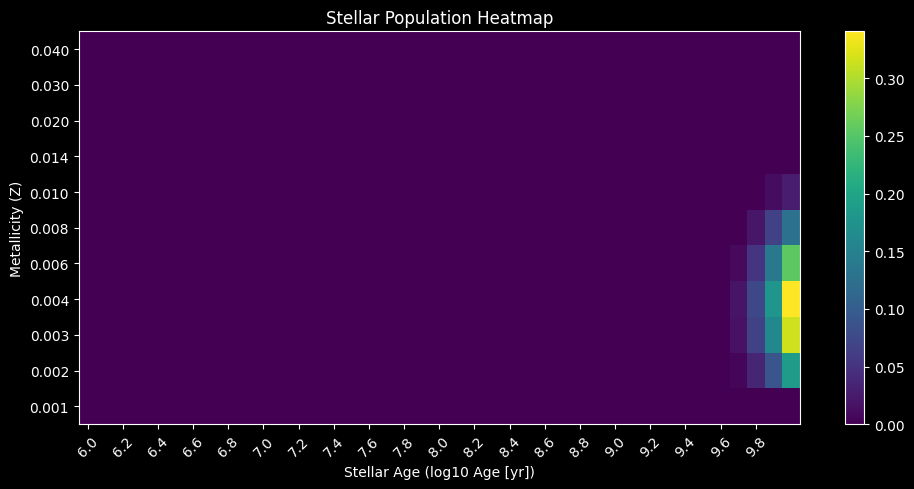

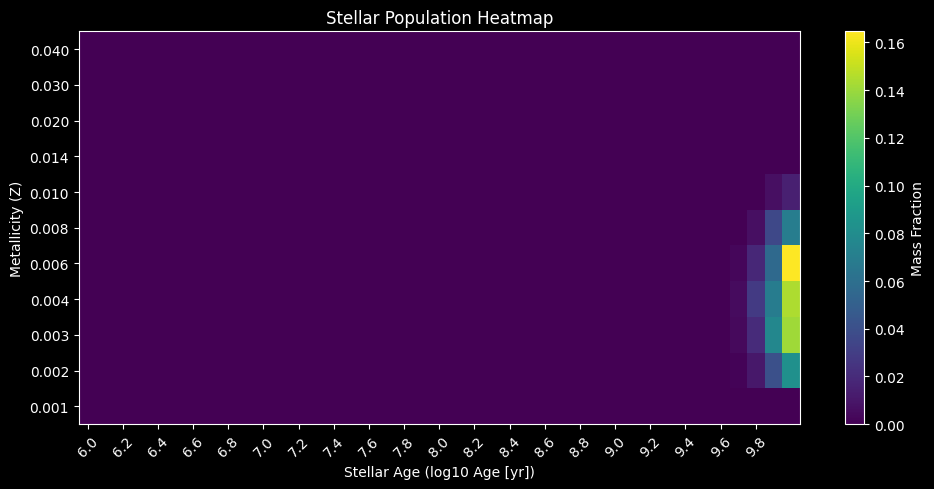

In [121]:
# you can also plot a heatmap of the contiuum compoents.
q3do.plot_comp_heatmap()

# By default, the heatmap is plotted for the weights PPXF assigned to the templates, 
# but we can plot the heatmap for othe values as well, lets plot for one of those.

#plottingmode = 'flux_fraction'
plottingmode = 'mass_fraction'

q3do.plot_comp_heatmap(plottingmode=plottingmode, savefig=True, plotargs={'mode': 'dark'})

Currently our templates include stellar populations much older than the age of the universe at the time of this galaxy. 

In [ ]:
# if the population decomposition isnt very good, or features unreasonable ages or metallicities, you can
# trim the templates used to a more reasonable range of ages and metallicities, and then re-run the fit
# you can also adjust your fitting parameters, and re-run the fit.

# lets generate a new template file with a more reasonable range of ages and metallicities, and then re-run the fitting routine, 
# dont re-run the cell that initialized the continuum fit, unless you want to overwrite the trimmed template file.

from q3dfit.templates import trim_templates

outfile = indir+'bpass_v2.3.a+00_z001to040_age060to101bin_lam2400to10000_trimmed.npy'

trim_templates(stellartemplates,
               outfile=outfile,
               zrange=[0.001, 0.040],
               agerange=[6., 10.1])

q3di.startempfile = outfile

# Now we can go back and re-run 2. Run Fit, and following cells

Trimmed templates saved to orc23c/bpass_v2.3.a+00_z001to040_bin_lam2400to10000_trimmed.npy


We can also re-run the fit with regularization, which will smooth the weights assigned to the templates.

In [ ]:
# if we want to, we can also add a ppxf regularization parameter to smooth out the stellar weights.
# for info on ppxf regularization, see https://pypi.org/project/ppxf/
# we need to first get the dimensions of the templates, to pass to ppxf via argscontfit
templates = np.load(q3di.startempfile, allow_pickle=True)[()]
nages = len(np.unique(templates['ages']))
nzs = len(np.unique(templates['zs']))

print(np.mean(templates['flux'][:,5]))

q3di.argscontfit['reg_dim'] = (nzs, nages)

# and then we can set the regularization parameter, which is a float value, with larger values resulting in more smoothing.
# the ppxf documentation provides some guidance on how to choose a good value, but we're just going to pick a value and see how it looks.
# lets just start with an initial guess of 10.0
q3di.argscontfit['regul'] = 10.0

1.0
